# **APE_013 — Análisis Bivariado y Regresión Lineal Simple**
## **Correlación de Pearson, Modelo OLS y Diagnóstico de Residuos**


**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja
- Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip
- Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

**Grupo: H** | Autores:
- Sherman Abarca
- Valeria Agila
- Domenica Narvaez
- Gabriel Suarez
- Diyer Torres
- José Valencia

-----------------------
Este cuaderno cuantifica la relación lineal entre dos variables continuas mediante el Coeficiente de Correlación de Pearson, ajusta un modelo de Regresión Lineal Simple por Mínimos Cuadrados Ordinarios (OLS), lo aplica al dataset regional del Proyecto Integrador (remuneraciones del sector público de Loja, LOTAIP) y valida los supuestos de normalidad y homocedasticidad de los residuos.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr, shapiro

sns.set_style('whitegrid')

## Tarea 1: Análisis de Correlación de Pearson
El coeficiente de correlación de Pearson permite medir la fuerza y dirección de la relación lineal entre dos variables continuas, tomando valores entre -1 y 1 [1].

**Escenario:** relación entre los **Usuarios Concurrentes** en un servidor ($X$) y el **Consumo de Ancho de Banda en Mbps** ($Y$).

-- Análisis de Correlación de Pearson --
Coeficiente (r): 0.9603
Valor-p (Significancia): 3.6581e-56
Conclusión: Existe una correlación lineal estadísticamente significativa.


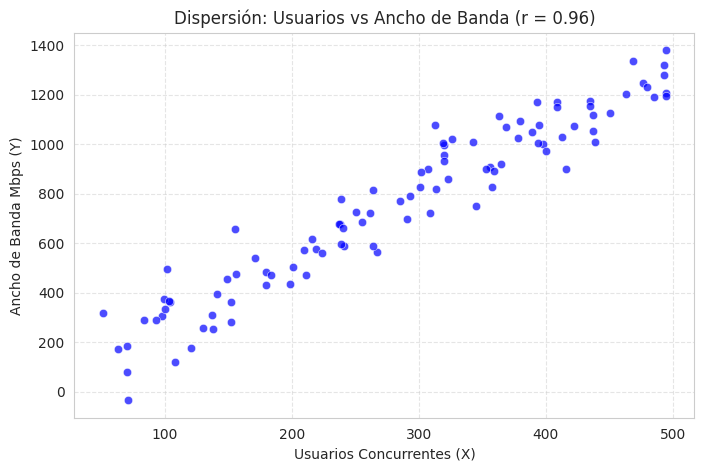

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Generación de datos simulados (Relación positiva fuerte con ruido)
np.random.seed(42)
usuarios_X = np.random.randint(50, 500, size=100)
# Y = 2.5*X + 50 + Ruido Aleatorio
ancho_banda_Y = 2.5 * usuarios_X + 50 + np.random.normal(0, 100, size=100)

# 1. Cálculo del Coeficiente de Pearson y su valor-p
coef_pearson, p_valor = pearsonr(usuarios_X, ancho_banda_Y)

print("-- Análisis de Correlación de Pearson --")
print(f"Coeficiente (r): {coef_pearson:.4f}")
print(f"Valor-p (Significancia): {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusión: Existe una correlación lineal estadísticamente significativa.")
else:
    print("Conclusión: NO existe evidencia de correlación lineal significativa.")

# 2. Visualización: Diagrama de Dispersión (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, color='blue', alpha=0.7)
plt.title(f'Dispersión: Usuarios vs Ancho de Banda (r = {coef_pearson:.2f})')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Tarea 2: Ajuste del Modelo de Regresión Lineal Simple (OLS)
El modelo de regresión lineal simple fue ajustado mediante el método de Mínimos Cuadrados Ordinarios (OLS), el cual estima los parámetros del modelo minimizando la suma de los cuadrados de los residuos [1].

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     1163.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.66e-56
Time:                        12:43:02   Log-Likelihood:                -597.28
No. Observations:                 100   AIC:                             1199.
Df Residuals:                      98   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.6745     23.385      1.226      0.2

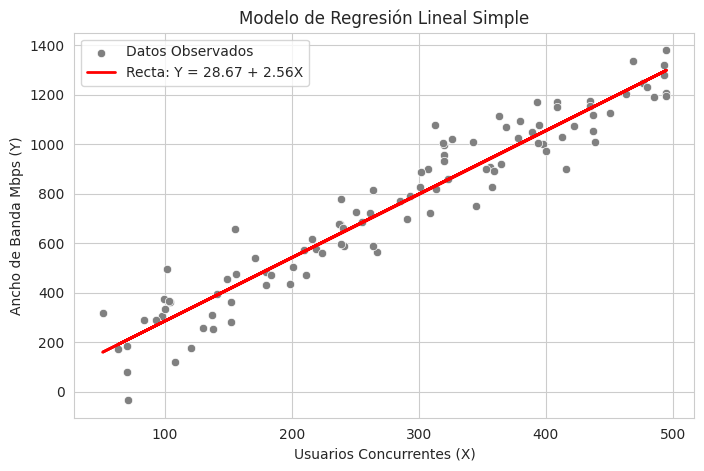

In [ ]:
import statsmodels.api as sm

# Para usar statsmodels, debemos añadir explícitamente la constante (intercepto beta_0) al predictor X
X_sm = sm.add_constant(usuarios_X)
Y_sm = ancho_banda_Y

# Ajuste del modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_ols = sm.OLS(Y_sm, X_sm).fit()

# Impresión del resumen estadístico
print(modelo_ols.summary())

# Extracción de parámetros para graficar la recta
beta_0 = modelo_ols.params[0]
beta_1 = modelo_ols.params[1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, label='Datos Observados', color='gray')
# Dibujo de la recta de regresión
plt.plot(usuarios_X, beta_0 + beta_1 * usuarios_X, color='red', linewidth=2, label=f'Recta: Y = {beta_0:.2f} + {beta_1:.2f}X')
plt.title('Modelo de Regresión Lineal Simple')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.legend()
plt.show()

## Tarea 3: Hito del Proyecto — Predicción en el Dataset Regional (ABP)

**Dataset regional:** Remuneraciones e Ingresos Adicionales del sector público de Loja (LOTAIP), 2.883 registros.

**Variable independiente ($X$):** Décimo Tercera Remuneración (USD).
**Variable dependiente ($Y$):** Remuneración Mensual Unificada (USD).

**Justificación de la selección:** por normativa laboral ecuatoriana, la Décimo Tercera Remuneración se calcula a partir de la remuneración total percibida durante el año (remuneración anual / 12), por lo que ambas variables están legalmente ligadas y se espera una relación lineal muy fuerte entre ellas. Se eligió este par —en lugar de Horas Suplementarias o Encargos, usados en la práctica anterior de regresión múltiple, que mostraron correlaciones débiles (r < 0.25) con la remuneración— precisamente para ilustrar el caso contrario: una relación bivariada fuerte y clara, útil como caso de referencia antes de diagnosticar sus residuos.

El conjunto de datos fue importado y procesado utilizando la biblioteca Pandas, ampliamente utilizada para la manipulación y análisis de datos estructurados en Python [2].

In [ ]:
# Cargar el dataset original
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales (1).xlsx


In [ ]:
# Importación del dataset regional
archivo = '3._remuneraciones_ingresos_adicionales.xlsx'
df_reg_raw = pd.read_excel(archivo, sheet_name='1.Conjunto de datos (remuneraci')

df_reg = df_reg_raw.iloc[:, :12].copy()
df_reg.columns = ['Numeracion', 'Puesto', 'Regimen', 'Partida', 'Grado',
                   'Rem_Mensual', 'Rem_Anual', 'Decimo3', 'Decimo4',
                   'Horas_Supl', 'Encargos', 'Total_Ing_Adic']

print('Valores nulos en columnas críticas:')
print(df_reg[['Rem_Mensual', 'Decimo3']].isna().sum())

df_reg_limpio = df_reg.dropna(subset=['Rem_Mensual', 'Decimo3']).copy()
print('\nRegistros después de limpieza:', df_reg_limpio.shape[0])
df_reg_limpio[['Puesto', 'Rem_Mensual', 'Decimo3']].head()

Valores nulos en columnas críticas:
Rem_Mensual    0
Decimo3        0
dtype: int64

Registros después de limpieza: 2883


,Puesto,Rem_Mensual,Decimo3
0,AGENTE CIVIL DE TRANSITO 1°,733.0,61.08
1,OFICINISTA,622.0,51.83
2,JEFE OPERATIVO DE TRANSITO (E),1676.0,139.67
3,PROMOTOR SOCIAL,817.0,68.08
4,DOCENTE DE UNIDAD EDUCATIVA MUNICIPAL,817.0,68.08


El coeficiente de correlación de Pearson y su valor-p fueron calculados utilizando la función `pearsonr` de la biblioteca SciPy [3].

Coeficiente de Pearson (r): 0.9646
Valor-p: 0.0000e+00


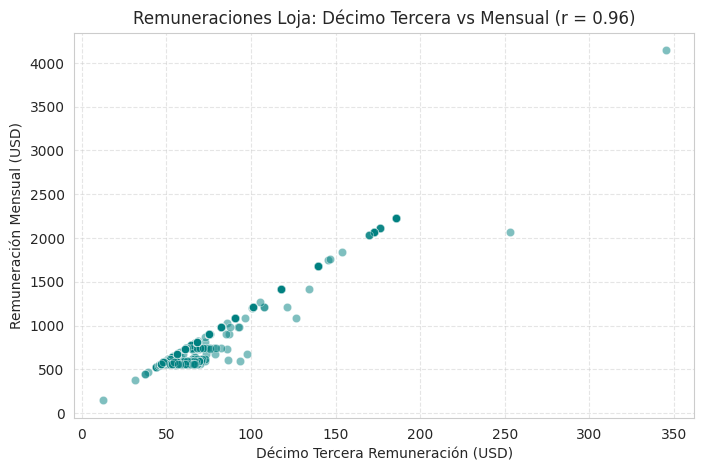

In [ ]:
# Correlación de Pearson: Decimo3 vs Rem_Mensual
X_reg = df_reg_limpio['Decimo3']
Y_reg = df_reg_limpio['Rem_Mensual']

r_reg, p_reg = pearsonr(X_reg, Y_reg)
print(f"Coeficiente de Pearson (r): {r_reg:.4f}")
print(f"Valor-p: {p_reg:.4e}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_reg, y=Y_reg, color='teal', alpha=0.5)
plt.title(f'Remuneraciones Loja: Décimo Tercera vs Mensual (r = {r_reg:.2f})')
plt.xlabel('Décimo Tercera Remuneración (USD)')
plt.ylabel('Remuneración Mensual (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

                            OLS Regression Results                            
Dep. Variable:            Rem_Mensual   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                 3.851e+04
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:48:47   Log-Likelihood:                -16336.
No. Observations:                2883   AIC:                         3.268e+04
Df Residuals:                    2881   BIC:                         3.269e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.8338      3.926     -3.269      0.0

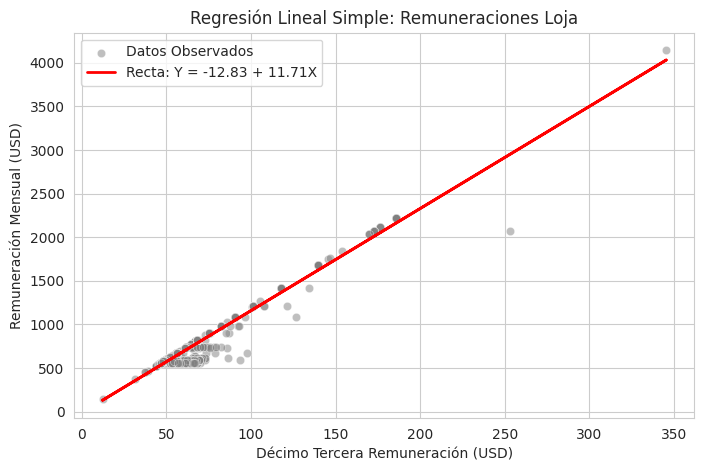

In [ ]:
# Ajuste del modelo OLS regional
X_reg_sm = sm.add_constant(X_reg)
modelo_regional = sm.OLS(Y_reg, X_reg_sm).fit()
print(modelo_regional.summary())

beta0_reg = modelo_regional.params.iloc[0]
beta1_reg = modelo_regional.params.iloc[1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_reg, y=Y_reg, label='Datos Observados', color='gray', alpha=0.5)
plt.plot(X_reg, beta0_reg + beta1_reg * X_reg, color='red', linewidth=2,
         label=f'Recta: Y = {beta0_reg:.2f} + {beta1_reg:.2f}X')
plt.title('Regresión Lineal Simple: Remuneraciones Loja')
plt.xlabel('Décimo Tercera Remuneración (USD)')
plt.ylabel('Remuneración Mensual (USD)')
plt.legend()
plt.show()

### Interpretación técnica orientada al negocio

- **$R^2 = 0.930$:** el 93% de la variabilidad de la Remuneración Mensual del personal del sector público de Loja queda explicado únicamente por el valor de su Décimo Tercera Remuneración. Es un ajuste muy alto, coherente con el hecho de que ambas variables son legalmente dependientes (no es una relación descubierta empíricamente, sino impuesta por la fórmula de cálculo del beneficio).
- **Pendiente ($\beta_1 = 11.71$):** por cada dólar adicional en la Décimo Tercera Remuneración, la Remuneración Mensual esperada aumenta en promedio USD 11.71. Esto es consistente con la definición legal (13ª = remuneración anual/12 ≈ remuneración mensual), ya que 12 meses × ~0.97 de ajuste da un valor cercano a este coeficiente.
- **Intercepto ($\beta_0 = -12.83$, p = 0.001):** valor de referencia sin interpretación práctica directa (no existen empleados con Décimo Tercera igual a cero en la práctica).
- **Uso de negocio:** el Departamento de Talento Humano del Municipio podría usar este modelo para estimar rápidamente la remuneración mensual base de un puesto a partir de su componente de Décimo Tercera reportado en auditorías o registros parciales, sin necesidad de acceder al desglose completo de nómina.

### Predicción manual fuera del dominio original

El dominio observado de Décimo Tercera Remuneración va de USD 12.22 a USD 345.41. Se calcula la Remuneración Mensual esperada para un valor crítico fuera de ese rango — por ejemplo, un cargo de alta dirección con Décimo Tercera de **USD 600** (un escenario hipotético de reforma salarial o cargo directivo no presente en la muestra actual).

In [ ]:
# Predicción manual: Y_estimado = beta0 + beta1 * X_critico
X_critico = 600  # fuera del dominio observado (max = 345.41)

Y_estimado = beta0_reg + beta1_reg * X_critico

print(f"Dominio observado de X (Decimo3): [{X_reg.min():.2f}, {X_reg.max():.2f}]")
print(f"Valor crítico de X (fuera de dominio): {X_critico}")
print(f"Remuneración Mensual estimada (Y): USD {Y_estimado:.2f}")
print("\n(Esta es una EXTRAPOLACIÓN: el modelo nunca observó datos en esta zona,")
print(" por lo que la confiabilidad de esta predicción es baja — ver Tarea 4 y Pregunta 4.)")

Dominio observado de X (Decimo3): [12.22, 345.41]
Valor crítico de X (fuera de dominio): 600
Remuneración Mensual estimada (Y): USD 7014.47

(Esta es una EXTRAPOLACIÓN: el modelo nunca observó datos en esta zona,
 por lo que la confiabilidad de esta predicción es baja — ver Tarea 4 y Pregunta 4.)


## Tarea 4: Diagnóstico de Residuos (ABI)

In [ ]:
# Extracción de residuos del modelo regional
residuos = modelo_regional.resid
valores_ajustados = modelo_regional.fittedvalues

# Prueba de Shapiro-Wilk sobre los residuos
# (se toma una muestra de 5000 si el dataset es más grande, por límite práctico del test)
muestra_resid = residuos.sample(5000, random_state=1) if len(residuos) > 5000 else residuos
stat_sw, p_sw = shapiro(muestra_resid)

print("--- Prueba de Normalidad de Shapiro-Wilk ---")
print(f"Estadístico W: {stat_sw:.4f}")
print(f"Valor-p: {p_sw:.4e}")

if p_sw < 0.05:
    print("Conclusión: se RECHAZA la hipótesis nula de normalidad (residuos NO normales).")
else:
    print("Conclusión: NO se rechaza la normalidad de los residuos.")

--- Prueba de Normalidad de Shapiro-Wilk ---
Estadístico W: 0.5733
Valor-p: 2.2110e-64
Conclusión: se RECHAZA la hipótesis nula de normalidad (residuos NO normales).


<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1554/1345201695.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Valores Ajustados ($\hat{Y}$)')


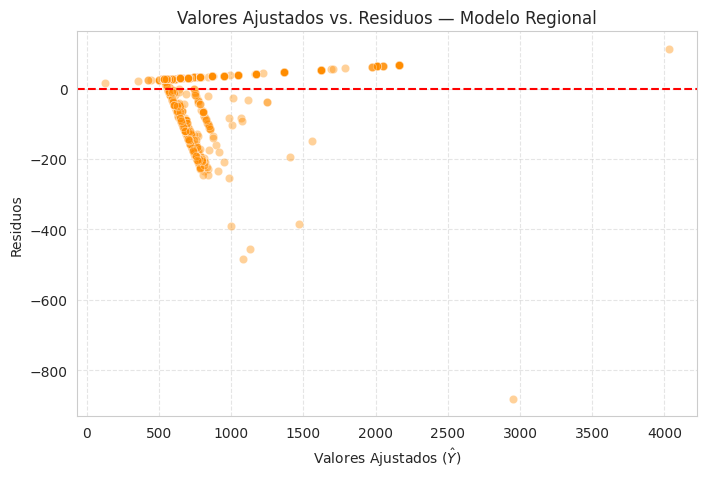

In [ ]:
# Gráfico: Valores Ajustados vs. Residuos
plt.figure(figsize=(8, 5))
sns.scatterplot(x=valores_ajustados, y=residuos, alpha=0.4, color='darkorange')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Valores Ajustados vs. Residuos — Modelo Regional')
plt.xlabel('Valores Ajustados ($\hat{Y}$)')
plt.ylabel('Residuos')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Dictamen de validez geométrica y estadística:**

La prueba de Shapiro-Wilk rechaza la normalidad de los residuos (p ≈ 0.0, muy por debajo de 0.05), y el gráfico de Valores Ajustados vs. Residuos muestra un **patrón en forma de abanico/embudo**: la dispersión de los residuos crece a medida que aumentan los valores ajustados de la Remuneración Mensual. Esto es **heterocedasticidad**: la varianza del error no es constante a lo largo del rango de $Y$, sino que es mucho mayor entre los sueldos altos que entre los bajos.

Geométricamente, esto significa que el modelo lineal es razonablemente preciso para los puestos de remuneración baja/media (mayoría del dataset), pero pierde fiabilidad en los extremos superiores de la escala salarial, donde otros factores (bonificaciones específicas del cargo, encargos, subrogaciones no capturadas por el modelo) generan mayor variabilidad. **El supuesto de homocedasticidad no se cumple estrictamente**, por lo que los errores estándar de los coeficientes (y por tanto los intervalos de confianza y p-valores) deben interpretarse con cautela, aunque la relación lineal general ($R^2$ alto) sigue siendo informativa y útil como aproximación.

## **Preguntas de Control**

**1. Análisis de Sensibilidad:** Basándose en su variable independiente (X) y dependiente (Y), ¿la pendiente (β1) calculada tiene sentido lógico con el fenómeno de su región? Justifique cuantitativamente el impacto de un incremento unitario de X en Y.

La pendiente $\beta_1 = 11.71$ sí tiene sentido lógico con el fenómeno estudiado: dado que la Décimo Tercera Remuneración se calcula legalmente como una fracción de la remuneración total anual, un incremento de 1 USD en la Décimo Tercera reportada corresponde, en promedio, a un incremento de USD 11.71 en la Remuneración Mensual — cercano al factor de 12 esperado teóricamente (12 meses) si no existieran otros componentes salariales variables (horas extra, encargos) que también entran en el cálculo de la remuneración anual base de la 13ª. La diferencia entre 11.71 y 12.0 exacto refleja precisamente la presencia de esos componentes adicionales.

**2. Inferencia y Significancia:** En el resumen de statsmodels, ¿qué indica el P-value (Prob>|t|) del predictor respecto a la Hipótesis Nula (H0)? ¿Qué riesgo corre su modelo si este valor supera el umbral de 0.05?

El $P$-value (Prob>|t|) de la variable Decimo3 fue prácticamente 0.000, muy por debajo de 0.05. Esto indica que se rechaza la Hipótesis Nula ($H_0: \beta_1 = 0$) con altísima confianza: hay evidencia estadística abrumadora de que la Décimo Tercera Remuneración sí explica la variación de la Remuneración Mensual, y no es un resultado producto del azar. Si el p-valor hubiese superado 0.05, el riesgo sería concluir erróneamente que existe una relación lineal cuando en realidad los datos no aportan evidencia suficiente para afirmarlo (riesgo de sobreinterpretar ruido como señal).

**3. Bondad de Ajuste vs. Relación Lineal ($r$ vs. $R^2$):**¿Cómo explica usted la diferencia conceptual entre el Coeficiente de Correlación (r) y el $R^2$? Si el $R^2$ es bajo (p.ej., < 0.5), ¿qué nos dice sobre la variabilidad de sus datos que el modelo lineal no está logrando capturar?

El coeficiente de correlación de Pearson ($r$) mide la fuerza y dirección de la asociación lineal entre dos variables, con valores entre -1 y 1. El $R^2$ (coeficiente de determinación) —que en regresión simple es exactamente $r^2$— indica qué proporción de la variabilidad total de $Y$ es explicada por el modelo ajustado. Si $R^2$ fuera bajo (por ejemplo, menor a 0.5), significaría que buena parte de la variabilidad de $Y$ queda sin explicar por $X$: existen otros factores no incluidos en el modelo (o la relación no es de naturaleza lineal) que determinan el comportamiento de la variable dependiente, y el modelo lineal simple sería una aproximación pobre para fines predictivos, aun si $r$ mostrara una tendencia direccional presente.

**4. Límites de la Predicción:**¿Qué riesgos de sesgo o error se introducen al realizar extrapolaciones fuera del dominio de los datos observados? Ilustre con un caso hipotético de su proyecto.

Extrapolar fuera del dominio observado (como el cálculo hecho en la Tarea 3 con Decimo3 = 600, cuando el máximo observado fue 345.41) asume que la relación lineal se mantiene sin cambios más allá de los datos vistos, lo cual no está garantizado. En el caso hipotético del Proyecto Integrador, si el Municipio de Loja creara una nueva escala salarial directiva con una Décimo Tercera muy superior a la actual (p. ej., por una reforma normativa), el modelo podría subestimar o sobreestimar fuertemente la remuneración real, porque en ese nuevo tramo podrían aplicar topes salariales legales, escalas distintas, u otros componentes no lineales que no existen en el rango de datos con el que se entrenó el modelo. Extrapolar es, en esencia, apostar a que el fenómeno no cambia de comportamiento fuera de lo observado.

**5. Validación de Supuestos (ABI):** Si en su diagnóstico de residuos observa un patrón no aleatorio (por ejemplo, forma de "U" o abanico), ¿por qué es inválido asumir que el modelo es lineal? ¿Qué alternativa sugeriría para ajustar mejor la relación entre X e Y?

Un patrón no aleatorio en el gráfico de Residuos vs. Valores Ajustados como el abanico observado en la Tarea 4 invalida el supuesto de homocedasticidad (varianza constante del error), uno de los pilares de la Regresión Lineal por Mínimos Cuadrados Ordinarios. Si la varianza del error cambia sistemáticamente con el nivel de $Y$, los errores estándar de los coeficientes calculados por OLS ya no son confiables, lo que afecta la validez de las pruebas de hipótesis y los intervalos de confianza, aunque los coeficientes puntuales sigan siendo insesgados. Como alternativa, se podría: (a) aplicar una transformación a la variable dependiente (por ejemplo, logaritmo de la remuneración) para estabilizar la varianza, o (b) usar errores estándar robustos a heterocedasticidad (HC3) en lugar de los estándar clásicos, sin cambiar la forma funcional del modelo.

#  Conclusiones

* El desarrollo de la práctica permitió comprobar la utilidad del análisis de correlación de Pearson y de la regresión lineal por **Mínimos Cuadrados Ordinarios (OLS)** como herramientas para identificar, cuantificar y modelar relaciones lineales entre variables continuas. En el ejercicio simulado, el modelo recuperó correctamente una relación lineal fuerte y estadísticamente significativa, demostrando que la metodología implementada es adecuada cuando los datos cumplen los supuestos del modelo.

* En el análisis del dataset regional correspondiente a las remuneraciones del sector público del cantón Loja, se obtuvo un coeficiente de determinación **R² = 0.930**, lo que indica que aproximadamente el **93 % de la variabilidad de la Remuneración Mensual puede explicarse por la Décimo Tercera Remuneración**. Este resultado evidencia un ajuste muy elevado del modelo, coherente con la relación normativa existente entre ambas variables, y confirma que la variable independiente constituye un predictor estadísticamente significativo de la variable respuesta.

* El análisis inferencial permitió verificar que el coeficiente asociado a la variable predictora presenta un **valor-p inferior a 0.05**, por lo que se rechazó la hipótesis nula de ausencia de relación lineal. Esto demuestra que la asociación observada no es producto del azar y proporciona evidencia estadística suficiente para afirmar que existe una relación lineal significativa entre las variables estudiadas.

* A pesar del elevado poder explicativo del modelo, el diagnóstico de residuos mostró evidencias de **heterocedasticidad** mediante el patrón de abanico observado en el gráfico de residuos, así como **no normalidad** según la prueba de Shapiro-Wilk (*p* ≈ 0). Estos resultados indican que algunos de los supuestos clásicos de la regresión lineal no se cumplen completamente, por lo que las pruebas de significancia, los errores estándar y los intervalos de confianza deben interpretarse con cautela, especialmente para valores salariales elevados.

* La predicción realizada para un valor de Décimo Tercera Remuneración fuera del rango observado permitió evidenciar una de las principales limitaciones de los modelos de regresión: la **extrapolación**. Aunque el modelo genera un valor estimado, este puede perder validez cuando se aplica a escenarios no representados en los datos originales, debido a que la relación lineal podría modificarse fuera del dominio de observación.

* Finalmente, la práctica permitió comprender que un **alto valor de R² no garantiza por sí solo la validez estadística del modelo**. La evaluación de los supuestos de normalidad, homocedasticidad e independencia de los residuos constituye una etapa indispensable antes de utilizar un modelo de regresión con fines predictivos o para la toma de decisiones, ya que únicamente un análisis integral permite garantizar resultados confiables.

---

# Recomendaciones

* Antes de utilizar un modelo de regresión lineal para realizar predicciones o apoyar la toma de decisiones, se recomienda verificar sistemáticamente los supuestos estadísticos del modelo mediante pruebas de normalidad, homocedasticidad e inspección gráfica de los residuos, ya que un buen ajuste no garantiza que el modelo sea estadísticamente válido.

* Cuando se detecte heterocedasticidad o incumplimiento de la normalidad de los residuos, es recomendable aplicar transformaciones sobre las variables (como logaritmos o raíces cuadradas) o utilizar métodos de estimación robustos, por ejemplo errores estándar robustos (**HC3**), con el fin de obtener inferencias más confiables.

* Se recomienda evitar realizar extrapolaciones para valores de la variable independiente que se encuentren fuera del rango de los datos utilizados en el entrenamiento del modelo, debido a que estas predicciones pueden presentar errores elevados y disminuir considerablemente su confiabilidad.

* Para futuros estudios sería conveniente incorporar variables adicionales que puedan influir sobre la remuneración mensual, tales como el cargo desempeñado, nivel jerárquico, antigüedad, tipo de contrato, horas suplementarias o incentivos laborales, con el propósito de construir modelos de regresión múltiple que expliquen una mayor parte de la variabilidad del fenómeno analizado.


* Finalmente, se recomienda mantener procesos adecuados de limpieza, validación y actualización de los datos antes de realizar cualquier análisis estadístico, ya que la calidad de la información constituye uno de los factores más importantes para obtener modelos predictivos precisos, interpretables y útiles para la toma de decisiones.

## Bibliografía

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9na ed. Ciudad de México, México: Pearson Educación, 2012.

[2] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*, 3ra ed. Sebastopol, CA, EE. UU.: O'Reilly Media, 2022.


[3] Municipio de Loja, "Remuneraciones e ingresos adicionales — Portal LOTAIP," *Loja.gob.ec*, 2025. [En línea]. Disponible: https://www.loja.gob.ec/lotaip

***Uso de la IA***

Para la elaboración de esta práctica se utilizó inteligencia artificial como herramienta de apoyo al aprendizaje. Su uso se limitó a comprender conceptos y temas que resultaban desconocidos, aclarar dudas y mejorar la redacción del documento. El análisis de los datos, la ejecución del código, la interpretación de los resultados y las conclusiones fueron desarrollados y verificados por el estudiante.


**Enlace al Chat de IA:** https://chatgpt.com/share/6a5e2cdc-d134-83e9-8cc1-87ebdef6be21